[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jen1995/jen1995.github.io/blob/main/notebooks/building_the_spectrogram.ipynb)

This notebook accompanies the post [From the Fourier Series to the Spectrogram, Part 3](https://jen1995.github.io/posts/fourier-series-to-spectrogram-part-3/): the STFT hand-rolled in three lines of numpy, leakage measured, the COLA property verified to machine precision, a spectrogram and a mel-spectrogram built from scratch — and, as the finale, the signal reassembled *back* from its STFT. Pure numpy + matplotlib, self-contained (the "voice" is synthesized inside).

# Building the spectrogram — with code

The plan mirrors the post, then goes further:

1. the STFT in three lines;
2. leakage, measured: on-grid vs off-grid tones;
3. windows, and the Hann sum-to-one trick (**verified**, including the fine print about the periodic variant);
4. a spectrogram of a synthetic voice, built and read;
5. the chirp and the time-frequency trade-off;
6. the mel filter bank as a matrix, and the pipeline accounting;
7. **the finale:** perfect reconstruction from the complex STFT — and why the *spectrogram* cannot be inverted so easily.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

BLUE, ORANGE, VIOLET, AQUA, GREY = "#2a78d6", "#eb6834", "#4a3aa7", "#1baf7a", "#8a8983"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

## 1. The STFT in three lines

`sliding_window_view` cuts the signal into frames, the window tapers each
frame, `rfft` transforms them all at once. That is the entire machine:

In [2]:
def stft(x, W, H, window=None):
    """Complex STFT: frames of length W every H samples, windowed, transformed."""
    if window is None:
        window = hann_periodic(W)
    frames = np.lib.stride_tricks.sliding_window_view(x, W)[::H]
    return np.fft.rfft(frames * window, axis=1)          # (n_frames, W//2 + 1)


def hann_periodic(W):
    """The DFT-friendly Hann window: denominator W, not W-1."""
    return 0.5 * (1 - np.cos(2 * np.pi * np.arange(W) / W))


def spectrogram(x, W, H, window=None):
    """Magnitudes of the STFT, laid out as (freq, time)."""
    return np.abs(stft(x, W, H, window)).T


def db(S, floor=-70):
    S = S / S.max()
    return np.maximum(20 * np.log10(S + 1e-12), floor)

## 2. Leakage, measured

A tone that completes a whole number of turns per frame gets one clean bin;
shift it by half a bin and the energy smears everywhere. Let us put numbers
on "everywhere": how much energy ends up *outside* the two nearest bins?

In [3]:
W = 256
n = np.arange(W)
for turns in [16.0, 16.5]:
    frame = np.sin(2 * np.pi * turns * n / W)
    S = np.abs(np.fft.rfft(frame))
    E = S ** 2
    near = E[int(turns) : int(turns) + 2].sum()
    print(f"{turns:5.1f} turns per frame:  energy outside the two nearest bins: "
          f"{100 * (1 - near / E.sum()):5.1f} %")

 16.0 turns per frame:  energy outside the two nearest bins:   0.0 %
 16.5 turns per frame:  energy outside the two nearest bins:  18.9 %


Nearly a *fifth* of a pure tone's energy scattered across the whole axis —
that is the torn seam of the periodized frame speaking. Now the fix.

## 3. Windows, and the sum-to-one trick

The Hann window tapers the frame to zero at both edges, so the glued copies
meet without a jump. The leakage skirt collapses:

In [4]:
hann = hann_periodic(W)
for turns in [16.5]:
    frame = np.sin(2 * np.pi * turns * n / W)
    for name, w in [("rectangular", np.ones(W)), ("Hann       ", hann)]:
        S = np.abs(np.fft.rfft(frame * w))
        E = S ** 2
        near = E[15:19].sum()   # a small neighborhood of the true frequency
        print(f"{name}:  energy outside bins 15-18:  {100 * (1 - near / E.sum()):6.2f} %")

rectangular:  energy outside bins 15-18:    9.89 %
Hann       :  energy outside bins 15-18:    0.09 %


And the post's overlap claim, verified to machine precision: shifted
*periodic* Hann windows at hop $H = W/2$ sum to exactly one — while the
symmetric variant (`np.hanning`, denominator $W-1$) leaves a small ripple,
and a lazy hop leaves a large one:

In [5]:
def overlap_sum(w, H, copies=50):
    W = len(w)
    total = np.zeros(H * copies + W)
    for m in range(copies):
        total[m * H : m * H + W] += w
    return total[W : -W]   # the steady-state interior


for name, w, H in [
    ("periodic Hann, hop W/2 ", hann_periodic(W), W // 2),
    ("symmetric Hann, hop W/2", np.hanning(W), W // 2),
    ("periodic Hann, hop 3W/4", hann_periodic(W), 3 * W // 4),
]:
    s = overlap_sum(w, H)
    print(f"{name}:  sum ranges over [{s.min():.6f}, {s.max():.6f}]")

periodic Hann, hop W/2 :  sum ranges over [1.000000, 1.000000]
symmetric Hann, hop W/2:  sum ranges over [0.993841, 0.999962]
periodic Hann, hop 3W/4:  sum ranges over [0.292893, 1.000000]


## 4. A spectrogram of a synthetic voice

To keep the notebook self-contained we synthesize a "voice": a stack of
harmonics riding a gliding fundamental (a vowel), a pause, a burst of noise
(a fricative), and a second vowel at a higher pitch. Three ingredients —
harmonics, silence, hiss — are exactly what we learned to read on a real
spectrogram in the post.

signal: 32000 samples  ->  spectrogram: 201 rows x 198 columns


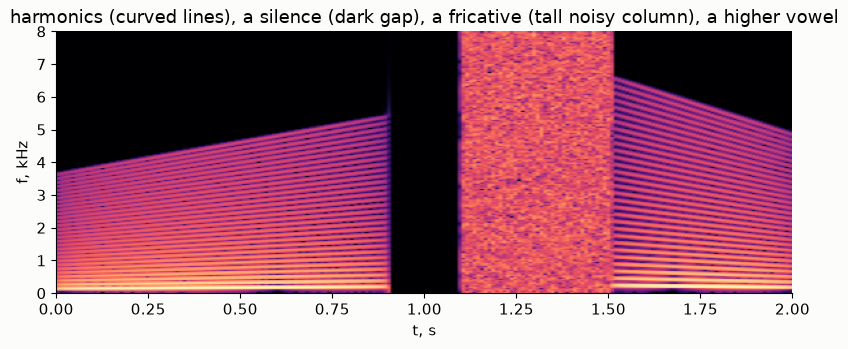

In [6]:
fs = 16000
def vowel(dur, f0_start, f0_end, n_harm=30):
    t = np.arange(int(fs * dur)) / fs
    f0 = np.linspace(f0_start, f0_end, len(t))
    phase = 2 * np.pi * np.cumsum(f0) / fs
    x = sum(np.sin(k * phase) / k for k in range(1, n_harm + 1))
    return x * np.hanning(len(x)) ** 0.15          # soft attack and release


rng = np.random.default_rng(0)
voice = np.concatenate([
    vowel(0.9, 120, 180),
    np.zeros(int(0.2 * fs)),
    0.5 * rng.standard_normal(int(0.4 * fs)),      # "fricative": white noise
    vowel(0.5, 220, 160),
])

W2, H2 = 400, 160                                   # 25 ms window, 10 ms hop
S = spectrogram(voice, W2, H2)
print(f"signal: {len(voice)} samples  ->  spectrogram: {S.shape[0]} rows x {S.shape[1]} columns")

plt.figure(figsize=(9.5, 3.4))
plt.imshow(db(S), origin="lower", aspect="auto", cmap="magma",
           extent=[0, len(voice) / fs, 0, fs / 2 / 1000])
plt.xlabel("t, s"); plt.ylabel("f, kHz")
plt.title("harmonics (curved lines), a silence (dark gap), a fricative (tall noisy column), a higher vowel")
plt.show()

## 5. The chirp and the trade-off

The post's law — frequency resolution is only resolution for signals that
hold still for the whole window — in one experiment:

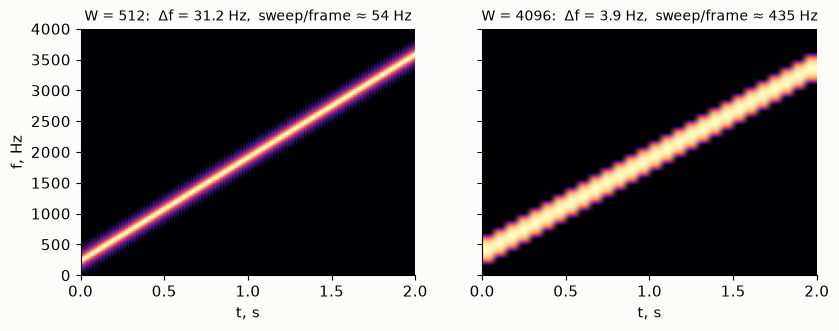

In [7]:
T_c, f0_c, f1_c = 2.0, 200, 3600
t_c = np.arange(int(fs * T_c)) / fs
chirp = np.sin(2 * np.pi * (f0_c * t_c + (f1_c - f0_c) / (2 * T_c) * t_c ** 2))
rate = (f1_c - f0_c) / T_c

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=True)
for ax, Wc in zip(axes, [512, 4096]):
    Sc = spectrogram(chirp, Wc, Wc // 4)
    ax.imshow(db(Sc), origin="lower", aspect="auto", cmap="magma",
              extent=[0, T_c, 0, fs / 2])
    ax.set_ylim(0, 4000); ax.set_xlabel("t, s")
    ax.set_title(f"W = {Wc}:  Δf = {fs / Wc:.1f} Hz,  sweep/frame ≈ {rate * Wc / fs:.0f} Hz",
                 fontsize=10)
axes[0].set_ylabel("f, Hz")
plt.show()

## 6. The mel filter bank, and the accounting

The mel scale, its inverse, and the triangular filters stacked into a
matrix — one filter per row:

F: (80, 201),  S: (201, 198)  ->  M = F @ S: (80, 198)
numbers:  waveform 32 000   S 39 798   M 15 840


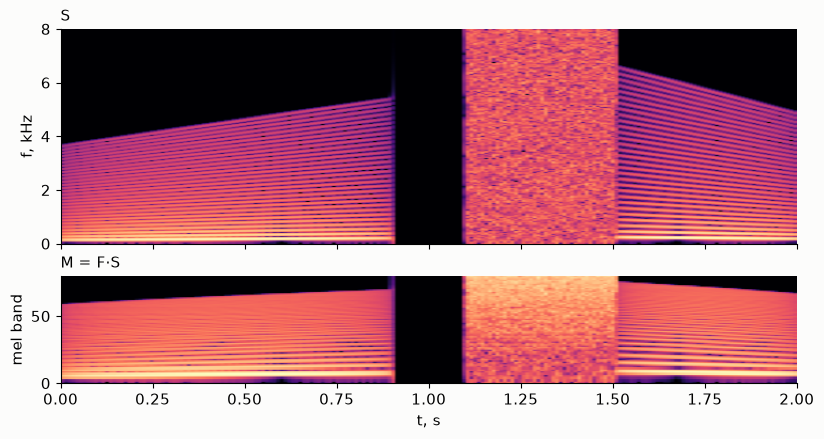

In [8]:
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)


def mel_to_hz(m):
    return 700 * (10 ** (m / 2595) - 1)


def mel_filterbank(n_mels, n_bins, fs):
    fmax = fs / 2
    pts = mel_to_hz(np.linspace(0, hz_to_mel(fmax), n_mels + 2))
    bins = np.floor((n_bins - 1) * pts / fmax).astype(int)
    F = np.zeros((n_mels, n_bins))
    for m in range(1, n_mels + 1):
        l, c, r = bins[m - 1], bins[m], bins[m + 1]
        if c > l:
            F[m - 1, l : c + 1] = (np.arange(l, c + 1) - l) / (c - l)
        if r > c:
            F[m - 1, c : r + 1] = (r - np.arange(c, r + 1)) / (r - c)
    return F


F = mel_filterbank(80, S.shape[0], fs)
M = F @ S
print(f"F: {F.shape},  S: {S.shape}  ->  M = F @ S: {M.shape}")
print(f"numbers:  waveform {len(voice):,}   S {S.size:,}   M {M.size:,}".replace(",", " "))

fig, axes = plt.subplots(2, 1, figsize=(9.5, 4.6), sharex=True, height_ratios=[2, 1])
axes[0].imshow(db(S), origin="lower", aspect="auto", cmap="magma",
               extent=[0, len(voice) / fs, 0, fs / 2 / 1000])
axes[0].set_ylabel("f, kHz"); axes[0].set_title("S", loc="left", fontsize=10.5)
axes[1].imshow(db(M), origin="lower", aspect="auto", cmap="magma",
               extent=[0, len(voice) / fs, 0, 80])
axes[1].set_ylabel("mel band"); axes[1].set_xlabel("t, s")
axes[1].set_title("M = F·S", loc="left", fontsize=10.5)
plt.show()

## 7. The finale: reconstruction from the STFT

The Hann sum-to-one property is not just bookkeeping — it is a *license to
rebuild*. Take the **complex** STFT (phases kept!), invert each frame back
into a windowed slice of signal, and lay the slices down at their hops,
adding where they overlap. Since the shifted windows sum to one, the
overlapping slices reassemble the signal exactly — this is called
**overlap-add**:

In [9]:
def istft(Z, W, H):
    frames = np.fft.irfft(Z, n=W, axis=1)
    y = np.zeros(H * (len(frames) - 1) + W)
    for m, fr in enumerate(frames):
        y[m * H : m * H + W] += fr
    return y


Z = stft(voice, W2, W2 // 2)                 # hop = W/2: the COLA condition
rebuilt = istft(Z, W2, W2 // 2)

lo, hi = W2, len(rebuilt) - W2               # trim the half-covered edges
print("perfect reconstruction:", np.allclose(rebuilt[lo:hi], voice[lo:hi]))

perfect reconstruction: True


Note carefully *what* we inverted: the complex STFT, phases and all. The
**spectrogram** — magnitudes only — cannot be inverted this way: the
phases are gone, and without them the frames do not know how to line up.
Rebuilding a waveform from a (mel-)spectrogram is a genuine estimation
problem — classically attacked by the Griffin–Lim algorithm, and in modern
speech synthesis by neural **vocoders**, which is why that word appears in
every text-to-speech paper. The spectrogram is a wonderful *analysis*
format and a lossy *synthesis* format — and knowing exactly what was lost
(the phase) and what survived (everything this series built) is the right
place for this road to end.

---

**What we now know how to do:** slice a signal into frames and transform
them in one vectorized stroke, measure leakage instead of fearing it,
verify a window's overlap property to machine precision, build and read a
spectrogram, budget the time-frequency trade, compress with a mel bank —
and reassemble the original signal from its frames, knowing exactly when
that is possible.